# EGFP design campaign — scaffold vs design vs target peaks

Visualize, for each of the 4 EGFP→target pairs, where the **scaffold** and **target** sit in
`(excitation, emission)` space and where the **guided designs** land, as **predicted by the
surrogate** (ESM-2 `cnn-max-d1`, all-data).

- **scaffold (measured)** and **target (measured)** — the real FPBase `(ex, em)` peaks.
- **design (surrogate)** — the surrogate's predicted `(ex, em)` for each of the 6 designed sequences
  per pair (final iteration), with the per-trial trajectory (rounds 0→3) drawn faintly.

> **No oracle for this task.** The design predictions come from the same surrogate that guided the
> search, so they are *in-sample / optimistic*, not independent validation. The scaffold and target
> markers are measured values; only the design markers are model predictions.

Data source: `guided_design/designs/design_*.csv` (produced by `guided_design/design_campaign.py`).

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_designs(designs_dir):
    fs = sorted(glob.glob(str(Path(designs_dir) / "design_*.csv")))
    d = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    d["pair"] = d["scaffold_name"] + " \u2192 " + d["target_name"]
    return d


def best_per_trial(d):
    """One row per (pair, trial): the ITERATION ROUND (>=1) with the smallest surrogate peak_err.
    Round 0 is the untouched scaffold and is EXCLUDED, so a 'best design' is always an actual edited
    sequence (never the original scaffold), even if every design is worse than the scaffold."""
    dd = d[d["round"] >= 1]
    idx = dd.groupby(["pair", "trial"])["peak_err"].idxmin()
    return dd.loc[idx].reset_index(drop=True)


def pair_summary(d):
    """Per pair: scaffold error (round 0) and mean/best over each trial's BEST round."""
    bt = best_per_trial(d)
    out = []
    for p, g in d.groupby("pair"):
        b = bt.loc[bt["pair"] == p, "peak_err"]
        out.append(dict(pair=p, scaffold_err=g.loc[g["round"] == 0, "peak_err"].iloc[0],
                        mean_design=b.mean(), best_design=b.min()))
    return pd.DataFrame(out).sort_values("best_design").reset_index(drop=True)


# locate guided_design/designs whether the notebook runs from the campaign root or the repo root
_cands = [Path("guided-design/designs"), Path("guided_design/designs"),
          Path("design-campaign-EGFP/guided-design/designs"),
          Path("design-campaign-EGFP/guided_design/designs"),
          Path.cwd() / "guided-design" / "designs", Path.cwd() / "guided_design" / "designs"]
DESIGNS = next((c for c in _cands if c.exists()), None)
assert DESIGNS is not None, "could not find guided_design/designs; run this notebook from design-campaign-EGFP/"
FIGDIR = DESIGNS.parent.parent / "figures"; FIGDIR.mkdir(exist_ok=True)

df = load_designs(DESIGNS)
RMAX = int(df["round"].max())
pairs = df.groupby("pair")["scaffold_idx"].first().index.tolist()
summary = pair_summary(df)
print(f"loaded {df['pair'].nunique()} pairs, {len(df)} rows | rounds 0..{RMAX} | trials {df.trial.nunique()}")
print(f"[each trial's best round] improved best over scaffold: "
      f"{(summary.best_design < summary.scaffold_err).sum()}/{len(summary)} | "
      f"best within 10 nm: {(summary.best_design < 10).sum()}/{len(summary)}")
summary.round(1)

loaded 4 pairs, 192 rows | rounds 0..3 | trials 12
[each trial's best round] improved best over scaffold: 4/4 | best within 10 nm: 3/4


,pair,scaffold_err,mean_design,best_design
0,EGFP → EBFP,88.3,3.5,0.0
1,EGFP → mEmerald,2.0,0.3,0.1
2,EGFP → mOrange,56.7,20.2,5.3
3,EGFP → mCherry,100.2,62.7,48.6


## Overview — all 4 pairs in (excitation, emission) space

One panel per pair. **Blue ●** = measured scaffold, **red ★** = measured target (the goal),
**green ○** = the 6 surrogate-predicted designs (final round), with the faint grey per-trial
trajectory from the scaffold's prediction (round 0) through each iteration. A hollow blue ○ marks
the surrogate's *prediction* for the scaffold (round 0) so you can see the surrogate's own bias
relative to the measured scaffold.

saved figures/campaign_peaks_overview.png


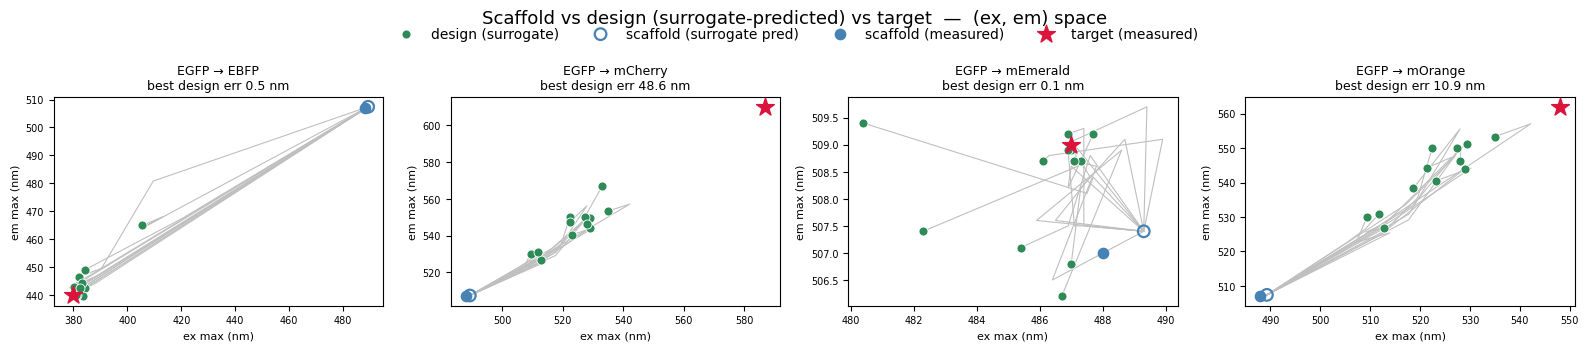

In [2]:
ncol = 4
nrow = int(np.ceil(len(pairs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.4 * nrow))
axes = axes.ravel()

for ax, p in zip(axes, pairs):
    g = df[df["pair"] == p]
    sc_ex, sc_em = g["scaffold_ex"].iloc[0], g["scaffold_em"].iloc[0]
    tg_ex, tg_em = g["target_ex"].iloc[0], g["target_em"].iloc[0]
    # per-trial trajectory (rounds 0..RMAX) in surrogate-predicted space
    for _, gt in g.groupby("trial"):
        gt = gt.sort_values("round")
        ax.plot(gt["pred_ex"], gt["pred_em"], "-", color="0.75", lw=0.8, zorder=1)
    gf = g[g["round"] == RMAX]
    g0 = g[g["round"] == 0].iloc[0]
    ax.scatter(gf["pred_ex"], gf["pred_em"], s=42, c="seagreen", edgecolor="white",
               linewidth=0.6, zorder=3, label="design (surrogate)")
    ax.scatter([g0["pred_ex"]], [g0["pred_em"]], s=70, facecolor="none", edgecolor="steelblue",
               linewidth=1.6, zorder=2, label="scaffold (surrogate pred)")
    ax.scatter([sc_ex], [sc_em], s=55, c="steelblue", zorder=4, label="scaffold (measured)")
    ax.scatter([tg_ex], [tg_em], s=180, c="crimson", marker="*", zorder=5, label="target (measured)")
    best = g.loc[g["round"] == RMAX, "peak_err"].min()
    ax.set_title(f"{p}\nbest design err {best:.1f} nm", fontsize=9)
    ax.set_xlabel("ex max (nm)", fontsize=8); ax.set_ylabel("em max (nm)", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[len(pairs):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, 1.005))
fig.suptitle("Scaffold vs design (surrogate-predicted) vs target  —  (ex, em) space", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_peaks_overview.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_peaks_overview.png")
plt.show()

## Interactive explorer

Pick a pair from the dropdown to inspect its 6 design trajectories in `(ex, em)` space. Hover any
point for the exact peaks. Requires `plotly` (falls back to a message if unavailable).

In [3]:
try:
    import plotly.graph_objects as go
    fig = go.Figure()
    trace_pair = []  # which pair each trace belongs to (for the dropdown)

    def add(pair_i, **kw):
        fig.add_trace(go.Scatter(visible=(pair_i == 0), **kw)); trace_pair.append(pair_i)

    for pi, p in enumerate(pairs):
        g = df[df["pair"] == p]
        sc_ex, sc_em = g["scaffold_ex"].iloc[0], g["scaffold_em"].iloc[0]
        tg_ex, tg_em = g["target_ex"].iloc[0], g["target_em"].iloc[0]
        xs, ys = [], []
        for _, gt in g.groupby("trial"):
            gt = gt.sort_values("round")
            xs += list(gt["pred_ex"]) + [None]; ys += list(gt["pred_em"]) + [None]
        add(pi, x=xs, y=ys, mode="lines", line=dict(color="lightgray", width=1),
            name="trajectory", showlegend=(pi == 0), hoverinfo="skip")
        gf = g[g["round"] == RMAX]
        add(pi, x=gf["pred_ex"], y=gf["pred_em"], mode="markers",
            marker=dict(color="seagreen", size=10, line=dict(width=1, color="white")),
            name="design (surrogate)", showlegend=(pi == 0),
            text=[f"trial {int(t)}, err {e:.1f} nm" for t, e in zip(gf["trial"], gf["peak_err"])],
            hovertemplate="design: ex %{x:.0f}, em %{y:.0f}<br>%{text}<extra></extra>")
        g0 = g[g["round"] == 0].iloc[0]
        add(pi, x=[g0["pred_ex"]], y=[g0["pred_em"]], mode="markers",
            marker=dict(symbol="circle-open", color="steelblue", size=13, line=dict(width=2)),
            name="scaffold (surrogate pred)", showlegend=(pi == 0),
            hovertemplate="scaffold pred: ex %{x:.0f}, em %{y:.0f}<extra></extra>")
        add(pi, x=[sc_ex], y=[sc_em], mode="markers",
            marker=dict(symbol="circle", color="steelblue", size=13),
            name="scaffold (measured)", showlegend=(pi == 0),
            hovertemplate="scaffold measured: ex %{x:.0f}, em %{y:.0f}<extra></extra>")
        add(pi, x=[tg_ex], y=[tg_em], mode="markers",
            marker=dict(symbol="star", color="crimson", size=17),
            name="target (measured)", showlegend=(pi == 0),
            hovertemplate="target measured: ex %{x:.0f}, em %{y:.0f}<extra></extra>")

    tp = np.array(trace_pair)
    buttons = [dict(label=p, method="update",
                    args=[{"visible": list(tp == pi)},
                          {"title": f"{p}   —   (ex, em) space (design = surrogate-predicted)"}])
               for pi, p in enumerate(pairs)]
    fig.update_layout(
        updatemenus=[dict(buttons=buttons, x=1.02, y=1.0, xanchor="left", showactive=True)],
        title=f"{pairs[0]}   —   (ex, em) space (design = surrogate-predicted)",
        xaxis_title="excitation max (nm)", yaxis_title="emission max (nm)",
        width=860, height=580, legend=dict(orientation="h", y=-0.16))
    fig.show()
except ModuleNotFoundError:
    print("plotly not installed — see the static overview above (pip install plotly to enable this).")

## Per-pair design error (surrogate)

How far the designs land from the target under the surrogate: the scaffold's starting error vs the
mean and best over the 6 trials, each taken at **its best round** (the round ≥ 1 minimizing surrogate
peak error — round 0 is the untouched scaffold and is excluded, so a "best design" is always an actual
edited sequence, never the scaffold), per pair (sorted by best). Again, these are the surrogate's own
predictions of designs it optimized — read as the design *objective*, not validation.

saved figures/campaign_design_error.png


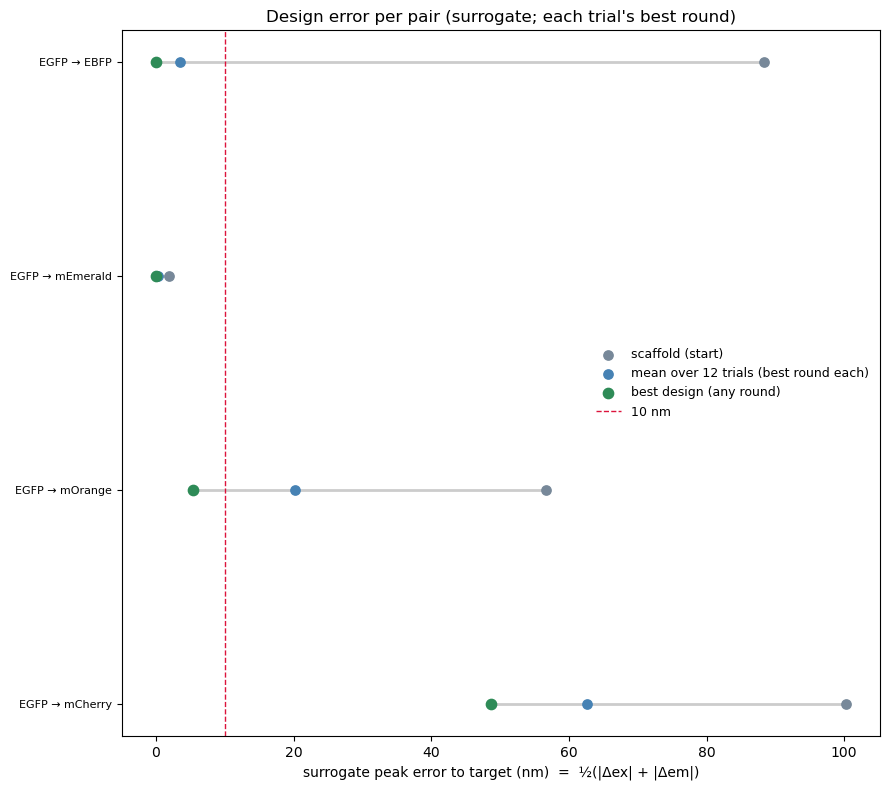

In [4]:
s = summary.sort_values("best_design").reset_index(drop=True)
y = np.arange(len(s))
fig, ax = plt.subplots(figsize=(9, 8))
ax.hlines(y, s["best_design"], s["scaffold_err"], color="0.8", lw=2, zorder=1)
n_trials = df.trial.nunique()
ax.scatter(s["scaffold_err"], y, s=45, c="lightslategray", label="scaffold (start)", zorder=2)
ax.scatter(s["mean_design"], y, s=45, c="steelblue", label=f"mean over {n_trials} trials (best round each)", zorder=3)
ax.scatter(s["best_design"], y, s=55, c="seagreen", label="best design (any round)", zorder=4)
ax.axvline(10, ls="--", color="crimson", lw=1, label="10 nm")
ax.set_yticks(y); ax.set_yticklabels(s["pair"], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("surrogate peak error to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
ax.set_title("Design error per pair (surrogate; each trial's best round)")
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_design_error.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_design_error.png")
plt.show()

## Gibbs-sampling designs

Gibbs sampling **never uses a target**, so its campaign now stores a single **target-free**
`gibbs-sampling/designs/design_<scaffold>.csv` (one design effort per scaffold) instead of four
byte-identical per-target CSVs. To compare it against the guided run on the same footing, we
reconstruct the per-target view in-memory: pair every (target-independent) Gibbs design with each
target's peaks and compute the same surrogate distance `peak_err = ½(|Δex| + |Δem|)`. This is
exactly what the four identical CSVs used to hold — the four "pairs" share one set of sequences.

In [5]:
_gcands = [Path("gibbs-sampling/designs"),
           Path("design-campaign-EGFP/gibbs-sampling/designs"),
           Path.cwd() / "gibbs-sampling" / "designs"]
GIBBS = next((c for c in _gcands if c.exists()), None)
assert GIBBS is not None, "could not find gibbs-sampling/designs"

# Gibbs is target-free (one design_<scaffold>.csv). Reconstruct the per-target view by pairing each
# design with every target's peaks (taken from the guided df) and recomputing the surrogate distance.
gbase = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(str(GIBBS / "design_*.csv")))],
                  ignore_index=True)
_targets = df[["target_name", "target_idx", "target_ex", "target_em"]].drop_duplicates()
dfg = gbase.merge(_targets, how="cross")
dfg["pair"] = dfg["scaffold_name"] + " \u2192 " + dfg["target_name"]
dfg["peak_err"] = 0.5 * ((dfg["pred_ex"] - dfg["target_ex"]).abs()
                         + (dfg["pred_em"] - dfg["target_em"]).abs())

RMAX_G = int(dfg["round"].max())
summary_g = pair_summary(dfg)
print(f"gibbs (target-free): {gbase['designed_seq'].nunique()} unique designs over "
      f"{gbase.trial.nunique()} trials \u00d7 {dfg['target_name'].nunique()} targets = "
      f"{dfg['pair'].nunique()} reconstructed views | rounds 0..{RMAX_G}")
print(f"[each trial's best round] improved best over scaffold: {(summary_g.best_design < summary_g.scaffold_err).sum()}"
      f"/{len(summary_g)} | best within 10 nm: {(summary_g.best_design < 10).sum()}/{len(summary_g)}")
summary_g.round(1)

gibbs (target-free): 37 unique designs over 12 trials × 4 targets = 4 reconstructed views | rounds 0..3
[each trial's best round] improved best over scaffold: 4/4 | best within 10 nm: 1/4


,pair,scaffold_err,mean_design,best_design
0,EGFP → mEmerald,2.0,11.6,1.0
1,EGFP → EBFP,88.4,57.7,39.5
2,EGFP → mOrange,56.6,66.7,51.4
3,EGFP → mCherry,100.2,110.2,94.9


### Per-pair design error — Gibbs sampling

Same lollipop as the guided run: scaffold's starting error → mean and best over the Gibbs trials,
each taken at **its best round** (round ≥ 1, i.e. an actual edited design, excluding the scaffold),
per pair (surrogate-predicted, sorted by best). In-sample/optimistic (surrogate scoring its own
designs). Note many Gibbs trials never beat the scaffold — their best *design* is still recorded so
these bars reflect genuine edits, not the original sequence.

saved figures/campaign_design_error_gibbs.png


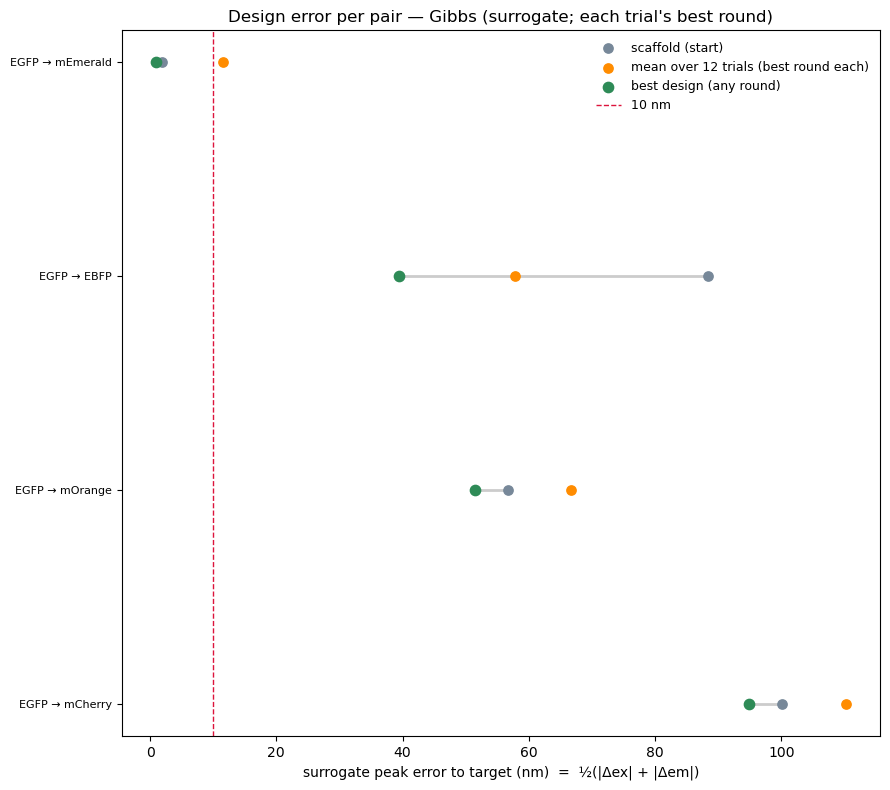

In [6]:
n_trials_g = dfg.trial.nunique()
s = summary_g.sort_values("best_design").reset_index(drop=True)
y = np.arange(len(s))
fig, ax = plt.subplots(figsize=(9, 8))
ax.hlines(y, s["best_design"], s["scaffold_err"], color="0.8", lw=2, zorder=1)
ax.scatter(s["scaffold_err"], y, s=45, c="lightslategray", label="scaffold (start)", zorder=2)
ax.scatter(s["mean_design"], y, s=45, c="darkorange", label=f"mean over {n_trials_g} trials (best round each)", zorder=3)
ax.scatter(s["best_design"], y, s=55, c="seagreen", label="best design (any round)", zorder=4)
ax.axvline(10, ls="--", color="crimson", lw=1, label="10 nm")
ax.set_yticks(y); ax.set_yticklabels(s["pair"], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("surrogate peak error to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
ax.set_title("Design error per pair — Gibbs (surrogate; each trial's best round)")
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_design_error_gibbs.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_design_error_gibbs.png")
plt.show()

## Guided vs Gibbs — per-peak distance to target

Distance of **each individual design** from its target, with the **excitation** and **emission**
peaks separated: `|Δex| = |pred_ex − target_ex|` and `|Δem| = |pred_em − target_em|`
(surrogate-predicted). Each point is one design attempt taken at **its best round** (the round ≥ 1 that
minimizes surrogate peak error — the scaffold at round 0 is excluded, so every point is a real edit).
The black bar marks the median.
Both guided and Gibbs draw 6 attempts/pair here.

saved figures/campaign_peak_distance_strip.png

peak        method      n   median    mean     p90
Excitation  guided     48     11.8    22.1    59.2
Excitation  gibbs      48     72.4    66.6   112.9
Emission    guided     48      7.8    21.2    61.9
Emission    gibbs      48     52.8    56.5   111.1


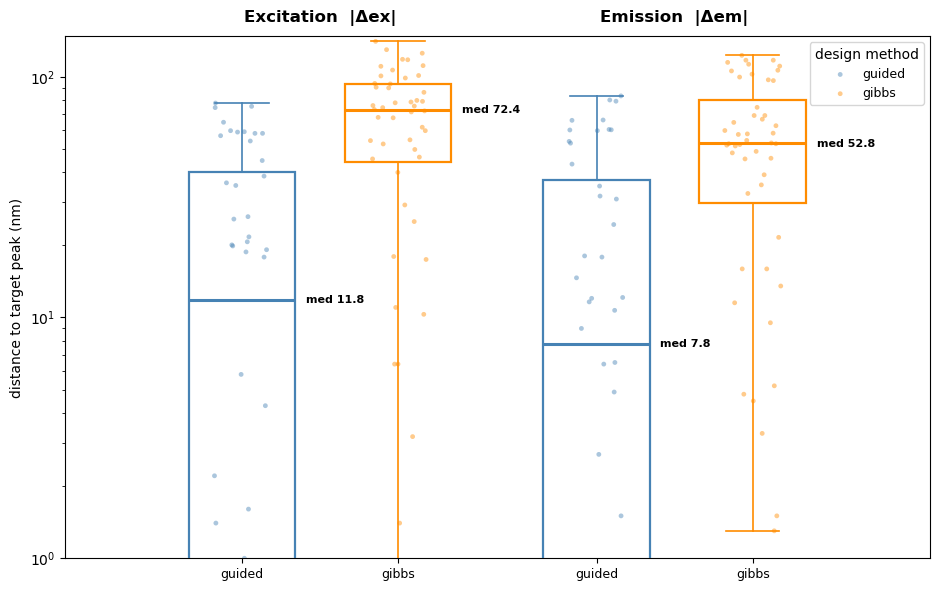

In [7]:
methods = [("guided", df, "steelblue"), ("gibbs", dfg, "darkorange")]
peaks = [("Excitation  |\u0394ex|", "pred_ex", "target_ex"),
         ("Emission  |\u0394em|", "pred_em", "target_em")]
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(9.5, 6))
tick_x, tick_lab = [], []
stats = []
for pk_i, (pk_label, pcol, tcol) in enumerate(peaks):
    for m_i, (mname, d, color) in enumerate(methods):
        fin = best_per_trial(d)   # each trial's best round (min surrogate peak_err)
        dist = (fin[pcol] - fin[tcol]).abs().to_numpy()
        cx = pk_i + (-0.22 if m_i == 0 else 0.22)
        # boxplot with TRANSPARENT facecolor (edges/median in the method colour)
        ax.boxplot([dist], positions=[cx], widths=0.30, showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor="none", edgecolor=color, linewidth=1.6),
                   medianprops=dict(color=color, linewidth=2.2),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.2), zorder=3)
        # stripplot: jittered individual designs over the box
        x = cx + rng.uniform(-0.08, 0.08, size=len(dist))
        ax.scatter(x, dist, s=12, c=color, alpha=0.45, edgecolor="none",
                   label=mname if pk_i == 0 else None, zorder=4)
        med = float(np.median(dist))
        ax.text(cx + 0.18, med, f"med {med:.1f}", ha="left", va="center", fontsize=8,
                fontweight="bold", zorder=6)
        tick_x.append(cx); tick_lab.append(mname)
        stats.append((pk_label.split()[0], mname, len(dist), med,
                      float(np.mean(dist)), float(np.percentile(dist, 90))))

ax.set_xticks(tick_x); ax.set_xticklabels(tick_lab, fontsize=9)
for pk_i, (pk_label, _, _) in enumerate(peaks):
    ax.text(pk_i, 1.02, pk_label, ha="center", va="bottom", fontsize=12,
            fontweight="bold", transform=ax.get_xaxis_transform())
ax.axhline(0, color="0.6", lw=0.8)
ax.set_ylabel("distance to target peak (nm)")
ax.set_ylim(bottom=1)
ax.set_yscale("log")
ax.legend(title="design method", fontsize=9, loc="upper right", frameon=True)
ax.margins(x=0.08)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_peak_distance_strip.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_peak_distance_strip.png\n")
print(f"{'peak':12}{'method':8}{'n':>5}{'median':>9}{'mean':>8}{'p90':>8}")
for pk, mn, n, md, me, p9 in stats:
    print(f"{pk:12}{mn:8}{n:>5}{md:>9.1f}{me:>8.1f}{p9:>8.1f}")
plt.show()

## Convergence — surrogate MAE vs iteration round

For each method, plot the surrogate MAE to target (`½(|Δex| + |Δem|)` = `peak_err`) against the
iteration round. At every round a single **unfilled boxplot** (`facecolor='none'`) summarizes the
distribution pooled across **all** shown designs; a **connected median** line and a **connected
minimum** line track the round-over-round trend. Every **design attempt** (one trial's trajectory) is
also overlaid faintly in its **pair's color** (round 0 is the shared scaffold starting point).

Tune `N_PAIRS_SHOW` / `N_TRIALS_SHOW` below to control which designs are pooled and overlaid.

saved figures/campaign_convergence_guided.png


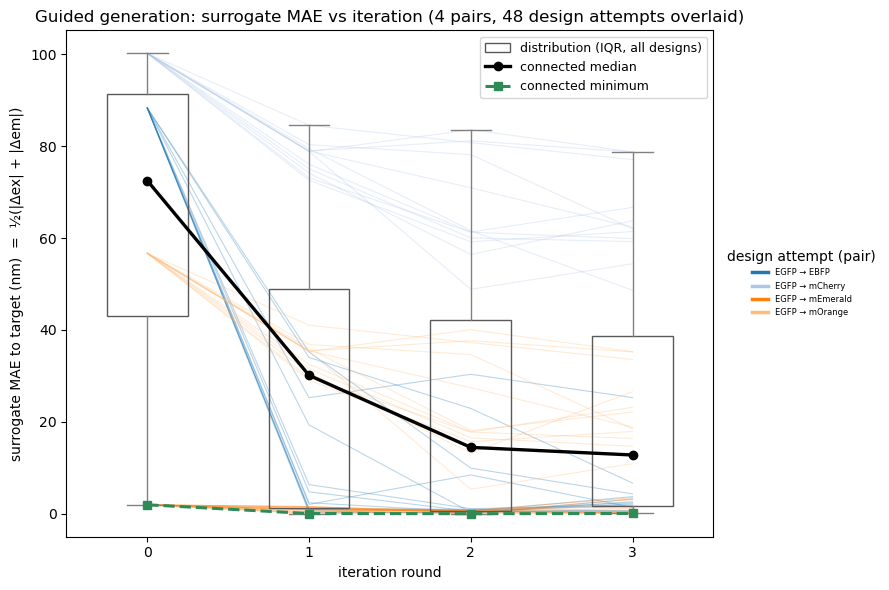

saved figures/campaign_convergence_gibbs.png


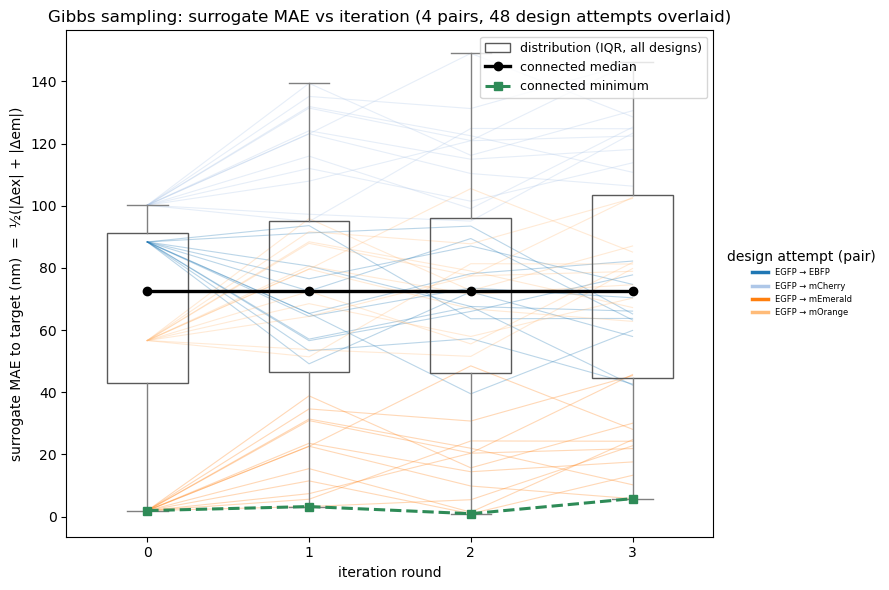

In [8]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---- tune which designs go into the aggregate distribution ------------------------
N_PAIRS_SHOW = 4         # number of scaffold->target pairs pooled into the boxplots
N_TRIALS_SHOW = None     # trials per pair pooled; None = all trials
# ----------------------------------------------------------------------------------


def plot_convergence(d, method_name, fname, n_pairs=N_PAIRS_SHOW, n_trials=N_TRIALS_SHOW):
    rmax = int(d["round"].max())
    rounds = list(range(rmax + 1))
    ps = d.groupby("pair")["scaffold_idx"].first().index.tolist()[:n_pairs]

    cmap = plt.get_cmap("tab20")
    pair_color = {p: cmap(i % 20) for i, p in enumerate(ps)}

    sub = d[d["pair"].isin(ps)].copy()
    if n_trials is not None:
        sub = sub[sub["trial"] < n_trials]

    # one aggregate distribution per round, pooled across ALL shown designs
    box_data = [sub.loc[sub["round"] == r, "peak_err"].to_numpy() for r in rounds]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.boxplot(box_data, positions=rounds, widths=0.5, showfliers=False, patch_artist=True,
               zorder=4, boxprops=dict(facecolor="none", edgecolor="0.35"),
               medianprops=dict(color="none"), whiskerprops=dict(color="0.5"),
               capprops=dict(color="0.5"))

    # overlay each individual design attempt (one trial's trajectory), colored by pair
    n_shown = 0
    for p in ps:
        for tr, gt in sub[sub["pair"] == p].groupby("trial"):
            gt = gt.sort_values("round")
            ax.plot(gt["round"], gt["peak_err"], "-", color=pair_color[p],
                    alpha=0.3, lw=0.8, zorder=2)
            n_shown += 1

    # connected median and connected minimum across rounds (over all pooled designs)
    meds = [float(np.median(b)) for b in box_data]
    mins = [float(np.min(b)) for b in box_data]
    ax.plot(rounds, meds, "-o", color="black", lw=2.4, ms=6, zorder=6)
    ax.plot(rounds, mins, "--s", color="seagreen", lw=2.2, ms=6, zorder=6)

    ax.set_xticks(rounds); ax.set_xlim(-0.5, rmax + 0.5)
    ax.set_xlabel("iteration round")
    ax.set_ylabel("surrogate MAE to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
    ax.set_title(f"{method_name}: surrogate MAE vs iteration "
                 f"({len(ps)} pairs, {n_shown} design attempts overlaid)")

    style_leg = ax.legend([Patch(facecolor="none", edgecolor="0.35"),
                           Line2D([0], [0], color="black", lw=2.4, marker="o"),
                           Line2D([0], [0], color="seagreen", lw=2.2, ls="--", marker="s")],
                          ["distribution (IQR, all designs)", "connected median", "connected minimum"],
                          loc="upper right", fontsize=9, frameon=True)
    ax.add_artist(style_leg)
    ax.legend([Line2D([0], [0], color=pair_color[p], lw=2.5) for p in ps], ps,
              fontsize=6, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, title="design attempt (pair)")
    fig.tight_layout()
    fig.savefig(FIGDIR / fname, dpi=130, bbox_inches="tight")
    print("saved", FIGDIR / fname)
    plt.show()


plot_convergence(df, "Guided generation", "campaign_convergence_guided.png")
plot_convergence(dfg, "Gibbs sampling", "campaign_convergence_gibbs.png")

## Are the designs in-distribution for the GFP-family DMS brightness models?

The DMS brightness models were trained on ESM-2 650M embeddings of large deep-mutational-scanning
libraries built on **four GFP scaffolds**: **avGFP** (Sarkisyan) plus the three orthologs
**amacGFP**, **cgreGFP**, and **ppluGFP**. To judge whether our EGFP designs are
**in-distribution (ID)** or **out-of-distribution (OOD)**, we compare embeddings directly:

- **DMS clouds** — **max-pooled** ESM-2 embeddings of **1,000 randomly sampled sequences per
  scaffold** (4,000 total), read from the cached per-residue embeddings
  (`avgfp_dms` → `esm_residue_fp16.npy`; `amacGFP`/`cgreGFP`/`ppluGFP` → `ortho_gfp_dms_esm_residue_fp16.npy`).
  Max-pool matches the CNN(1)-max model's own pooling, so this is the representation closest to what
  the models actually key on.
- **Designs** — the unique designed sequences (guided + gibbs, all iterations), reframed to the DMS
  window (`seq[3:238]`) and **max-pooled** the same way, so the comparison is apples-to-apples.

We (1) project everything onto PCA axes fit on the **combined 4-scaffold cloud** so you can see which
scaffold family each design lands in, and (2) quantify OOD-ness with the distance from each design to
its nearest DMS neighbor (standardized embedding space) versus the DMS's own internal
nearest-neighbor distances. Designs sitting outside the clouds / with large NN distances are
extrapolations the brightness models cannot be trusted on.

In [9]:
# Build max-pooled ESM-2 embeddings for 1k sequences per GFP scaffold + the (reframed) unique designs.
import sys, torch
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# locate repo root (folder holding the GFP DMS cache) whether cwd is the campaign dir or the repo
HERE = Path.cwd()
REPO = next((b for b in [HERE, *HERE.parents]
             if any((b / d / "DMS_data").exists() for d in ("avGFP_DMS", "GFP_DMS"))), HERE.parent)
DMSD = next(REPO / d / "DMS_data" for d in ("avGFP_DMS", "GFP_DMS")
            if (REPO / d / "DMS_data").exists())
sys.path.insert(0, str(REPO / "esm2_design"))
import peak_models as pm
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("repo:", REPO, "| DMS:", DMSD.name, "| device:", dev)

# ---- DMS clouds: MAX-pool 1,000 random seqs from EACH of the 4 GFP scaffolds (cache to disk) ----
# avGFP lives in its own cache; amacGFP/cgreGFP/ppluGFP share the "ortho" cache. Each cache row is
# aligned 1:1 with its CSV, so we sample CSV row-indices and read those rows from the .npy.
N_PER = 1000
SCAFFOLDS = ["avGFP", "amacGFP", "cgreGFP", "ppluGFP"]
SRC = {  # scaffold -> (sequences csv, residue-embedding .npy, residue-length .npy, brightness col)
    "avGFP":   ("avgfp_dms_sequences.csv",     "esm_residue_fp16.npy",            "esm_residue_len.npy",            "logMedianBrightness"),
    "amacGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
    "cgreGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
    "ppluGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
}
MP_CACHE = DMSD / f"esm_maxpool_4scaffold_{N_PER//1000}k.npz"

def _maxpool_rows(Hpath, Lpath, rows):
    H = np.load(Hpath, mmap_mode="r"); Ls = np.load(Lpath).astype(int)
    out = np.zeros((len(rows), H.shape[2]), np.float32)
    for t, i in enumerate(rows):
        n = int(Ls[i]); r = np.asarray(H[i]).astype(np.float32)
        out[t] = r[:n].max(0) if n else 0.0
    return out

if MP_CACHE.exists():
    _z = np.load(MP_CACHE, allow_pickle=True)
    mp, scaf_lab, y_dms = _z["mp"], _z["scaf"].astype(str), _z["y"]
    print(f"loaded cached 4-scaffold max-pool {mp.shape}")
else:
    rng0 = np.random.default_rng(0)
    parts, labs, ys = [], [], []
    for s in SCAFFOLDS:
        csv, emb, lenf, ycol = SRC[s]
        d = pd.read_csv(DMSD / csv)
        idx = d.index[d["scaffold"] == s].to_numpy() if "scaffold" in d.columns else d.index.to_numpy()
        take = np.sort(rng0.choice(idx, size=min(N_PER, len(idx)), replace=False))
        parts.append(_maxpool_rows(DMSD / emb, DMSD / lenf, take))
        labs.append(np.full(len(take), s)); ys.append(d[ycol].to_numpy()[take])
        print(f"  {s}: max-pooled {len(take)} / {len(idx)} available")
    mp = np.concatenate(parts); scaf_lab = np.concatenate(labs); y_dms = np.concatenate(ys)
    np.savez(MP_CACHE, mp=mp, scaf=scaf_lab, y=y_dms)
    print(f"cached 4-scaffold max-pool {mp.shape} -> {MP_CACHE.name}")

# per-scaffold consensus of the avGFP DMS = avGFP parent (235 aa) reference point
_dms_av = pd.read_csv(DMSD / "avgfp_dms_sequences.csv")
_arr = np.array([list(s) for s in _dms_av["mutatedSequence"].values])
PARENT235 = "".join(Counter(_arr[:, j]).most_common(1)[0][0] for j in range(_arr.shape[1]))

# ---- Designs: unique sequences (guided + gibbs, iterations >=1), reframed to the DMS window ----
alld = pd.concat([df.assign(_method="guided"), dfg.assign(_method="gibbs")], ignore_index=True)
alld = alld[alld["round"] >= 1]
uniq = alld.drop_duplicates("designed_seq").copy()
egfp = df["scaffold_seq"].iloc[0]
egfp235 = egfp[3:238]
uniq["seq235"] = uniq["designed_seq"].str[3:238]
uniq["nmut"] = uniq["seq235"].apply(lambda s: sum(a != b for a, b in zip(s, egfp235)))
print(f"unique designs: {len(uniq)} | mutation load vs EGFP: {uniq['nmut'].min()}-{uniq['nmut'].max()}")

@torch.no_grad()
def max_embed(seqs, bs=64):
    """Masked max-pool of ESM-2 650M per-residue embeddings -> (n, 1280) (matches CNN(1)-max)."""
    out = []
    for i in range(0, len(seqs), bs):
        Hh, mm = pm.resid_embed(list(seqs[i:i + bs]), dev)
        out.append(pm.masked_pool(Hh, mm, "max").float().cpu().numpy())
    return np.concatenate(out)

dmp = max_embed(uniq["seq235"].tolist())             # designs
ref = max_embed([egfp235, PARENT235])                # EGFP scaffold + avGFP parent
egfp_mp, parent_mp = ref[0:1], ref[1:2]
print("design embeddings:", dmp.shape)

# ---- PCA fit on the COMBINED 4-scaffold cloud; project everything ----
mu, sd = mp.mean(0), mp.std(0) + 1e-6
Z = (mp - mu) / sd
pca = PCA(n_components=2, random_state=0).fit(Z)
P_dms = pca.transform(Z)
P_des = pca.transform((dmp - mu) / sd)
P_egfp = pca.transform((egfp_mp - mu) / sd)
P_par = pca.transform((parent_mp - mu) / sd)

# ---- OOD metric: NN distance (standardized space) design->DMS vs DMS internal ----
rng = np.random.default_rng(0)
Zd = (dmp - mu) / sd
nn = NearestNeighbors(n_neighbors=1).fit(Z)          # reference = the full 4k DMS sample
d_des, _ = nn.kneighbors(Zd)                          # each design -> nearest DMS (any scaffold)
nn2 = NearestNeighbors(n_neighbors=2).fit(Z)
d_dms, _ = nn2.kneighbors(Z)                          # DMS internal (2nd nbr excludes self)
d_des, d_dms = d_des.ravel(), d_dms[:, 1]
p99 = np.percentile(d_dms, 99)
frac_ood = float((d_des > p99).mean())

# which scaffold family is each design nearest to?
near_by_scaf = {}
for s in SCAFFOLDS:
    m = scaf_lab == s
    near_by_scaf[s] = NearestNeighbors(n_neighbors=1).fit(Z[m]).kneighbors(Zd)[0].ravel()
nearest_scaf = np.array(SCAFFOLDS)[np.argmin(np.column_stack([near_by_scaf[s] for s in SCAFFOLDS]), 1)]

print(f"\nNN-distance (standardized embedding):")
print(f"  DMS internal   median {np.median(d_dms):.2f}   99th pct {p99:.2f}")
print(f"  designs->DMS   median {np.median(d_des):.2f}   range {d_des.min():.2f}-{d_des.max():.2f}")
print(f"  designs beyond DMS 99th-pct NN distance: {frac_ood:.1%}")
print("  nearest-scaffold family for designs:",
      {s: int((nearest_scaf == s).sum()) for s in SCAFFOLDS})

repo: /home/ubuntu/spectrum-to-fp-design | DMS: DMS_data | device: cuda


  avGFP: max-pooled 1000 / 51715 available


  amacGFP: max-pooled 1000 / 33511 available


  cgreGFP: max-pooled 1000 / 24516 available


  ppluGFP: max-pooled 1000 / 31402 available
cached 4-scaffold max-pool (4000, 1280) -> esm_maxpool_4scaffold_1k.npz


unique designs: 148 | mutation load vs EGFP: 13-25


design embeddings: (148, 1280)



NN-distance (standardized embedding):
  DMS internal   median 15.83   99th pct 34.09
  designs->DMS   median 42.35   range 31.76-61.44
  designs beyond DMS 99th-pct NN distance: 96.6%
  nearest-scaffold family for designs: {'avGFP': 148, 'amacGFP': 0, 'cgreGFP': 0, 'ppluGFP': 0}


saved figures/campaign_dms_ood_4scaffold.png


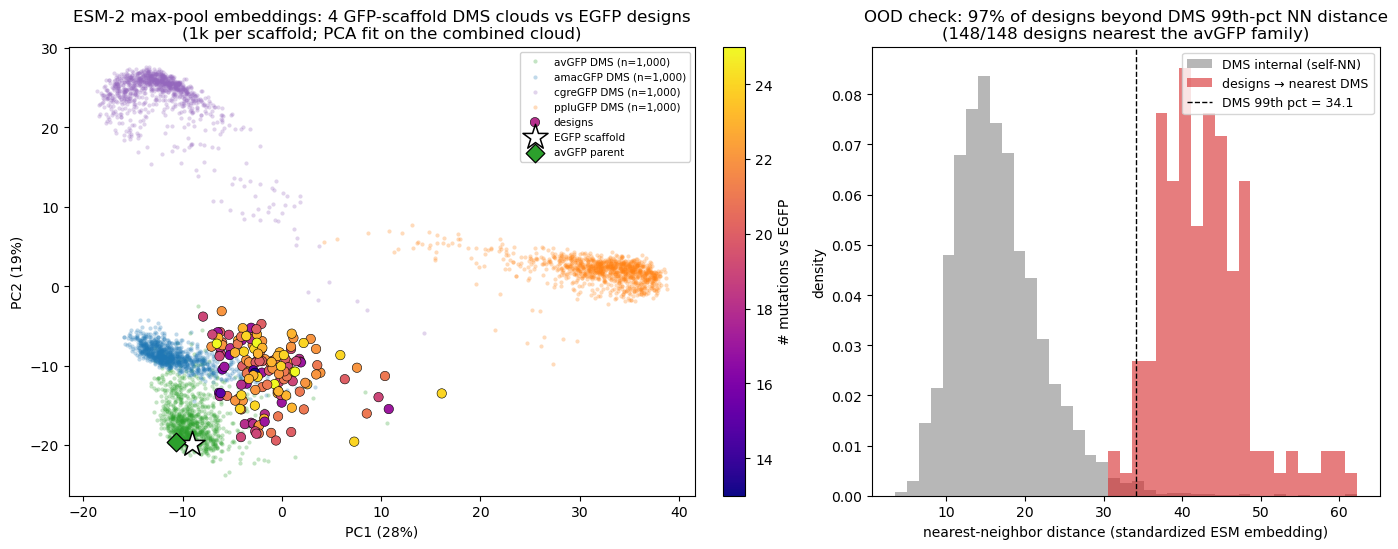

In [10]:
# Left: PCA of the 4 GFP-scaffold DMS clouds vs designs. Right: OOD NN-distance histograms.
fig, (axP, axH) = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.35, 1]})

# --- PCA scatter: one pale cloud per scaffold (1k each) + designs colored by mutation load ---
SCAF_COLORS = {"avGFP": "#2ca02c", "amacGFP": "#1f77b4", "cgreGFP": "#9467bd", "ppluGFP": "#ff7f0e"}
for s in SCAFFOLDS:
    m = scaf_lab == s
    axP.scatter(P_dms[m, 0], P_dms[m, 1], s=9, c=SCAF_COLORS[s], alpha=0.28,
                linewidths=0, zorder=1, label=f"{s} DMS (n={int(m.sum()):,})")
scm = axP.scatter(P_des[:, 0], P_des[:, 1], c=uniq["nmut"], cmap="plasma", s=46,
                  edgecolor="k", linewidth=0.4, zorder=3, label="designs")
axP.scatter(*P_egfp[0], marker="*", s=360, c="w", edgecolor="k", linewidth=1.1,
            zorder=4, label="EGFP scaffold")
axP.scatter(*P_par[0], marker="D", s=90, c="#2ca02c", edgecolor="k", linewidth=0.9,
            zorder=4, label="avGFP parent")
axP.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axP.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axP.set_title("ESM-2 max-pool embeddings: 4 GFP-scaffold DMS clouds vs EGFP designs\n"
              "(1k per scaffold; PCA fit on the combined cloud)")
fig.colorbar(scm, ax=axP, label="# mutations vs EGFP", fraction=0.046, pad=0.04)
axP.legend(loc="best", fontsize=7.5, framealpha=0.9)

# --- NN-distance histograms (OOD): DMS internal vs designs, per-scaffold nearest overlaid ---
lo = min(d_dms.min(), d_des.min()); hi = max(d_dms.max(), d_des.max())
bins = np.linspace(lo, hi, 40)
axH.hist(d_dms, bins=bins, density=True, color="0.6", alpha=0.7, label="DMS internal (self-NN)")
axH.hist(d_des, bins=bins, density=True, color="#d62728", alpha=0.6, label="designs \u2192 nearest DMS")
axH.axvline(p99, ls="--", color="k", lw=1, label=f"DMS 99th pct = {p99:.1f}")
axH.set_xlabel("nearest-neighbor distance (standardized ESM embedding)")
axH.set_ylabel("density")
_topscaf, _topn = Counter(nearest_scaf).most_common(1)[0]
axH.set_title(f"OOD check: {frac_ood:.0%} of designs beyond DMS 99th-pct NN distance\n"
              f"({_topn}/{len(d_des)} designs nearest the {_topscaf} family)")
axH.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGDIR / "campaign_dms_ood_4scaffold.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_dms_ood_4scaffold.png")
plt.show()